# Train new Magnetization model

Requires environment defined in /environment-jpnb.yml

## Settings

In [12]:
# using IPython to autoreload modules when they are edited
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import numpy as np
import random
import os
os.environ["KERAS_BACKEND"] = "jax"  
import keras
from sklearn.metrics import r2_score
from ml.bnn_special import BnnMs
from evaluation.residual import plot_cv_predictions_color_std
from evaluation.confidence import plot_confidence
from evaluation.residual import residual_plot
from util import load_experimental, get_timestamp_as_string, DATA_PATH, MODEL_PATH
print('Imports OK')

Imports OK


In [14]:
TS = get_timestamp_as_string()
print(f"Timestamp: {TS}")
symbol = r"$\mu_0M_\mathrm{s}$"
MODEL_SAVE_PATH = MODEL_PATH / "Ms_bnn" / TS
MODEL_SAVE_PATH.mkdir(parents=True, exist_ok=True)
SEED = 123
np.random.seed(SEED)
random.seed(SEED)
keras.utils.set_random_seed(SEED)

Timestamp: 2026-01-19__20-37-51


# Train new model 

## Get data

In [15]:
# Load experimental data
df = load_experimental(file_name="2025-06-05_physical_properties.csv", dir_name=DATA_PATH)
print(f"loaded initial data with shape: {df.shape}")

Load data from '2025-06-05_physical_properties.csv'
No features provided for duplicate removal. Using default features: ['Nd', 'Ce', 'La', 'Pr', 'Y', 'Tb', 'Dy', 'Fe', 'Co', 'Ni', 'B', 'C', 'temp']
Dropped 40 duplicates.
Applied sphere transform to elemental features.
Scaled 'temp' feature to 'temp_s' by dividing by max temp.
loaded initial data with shape: (1479, 39)


In [16]:
# Select scaled data
features_physics = ['Nd_s', 'Ce_s', 'La_s', 'Pr_s', 'Y_s', 'Tb_s', 'Dy_s', 'Fe_s', 'Co_s', 'Ni_s', 'B_s', 'C_s', "temp_s"]
df = df[features_physics + ["Ms"]].copy()

# Split data into features and target
X = df.drop("Ms", axis=1)
y = df["Ms"]

## Fit model

In [17]:
regressor: BnnMs = BnnMs(n_features=len(features_physics), random_seed=SEED)
print("fitting regressor for prediction ...")
regressor.fit(X, y)

fitting regressor for prediction ...
Fitting started at:  2026-01-19 20:37:52
Fitting finished at: 2026-01-19 20:38:26
Total fitting time of BnnMs.Bnn_Magnetization: 34.00 seconds
----------------------------------------------------------------------


### Write model architecture to file and output 

In [18]:
# Write model summary to file
model_summary_path = MODEL_SAVE_PATH / "Ms_model_summary.txt"
summary = str(regressor.summary())
print(summary)
with open(model_summary_path, "w") as f:
    f.write(summary)

****************************************************************************
Model: "Bnn_Magnetization"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 64)   

### Save model to disk

In [19]:
regressor.save_model_to_disk(MODEL_SAVE_PATH / "Ms_model")

Keras model saved to: /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ms_bnn/2026-01-19__20-37-51/Ms_model.keras
Estimator attributes saved to: /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ms_bnn/2026-01-19__20-37-51/Ms_model.joblib


# Evaluation

## Prediction accuracy

### Perform 5-fold cross validation

In [20]:
(y_pred_cv_all, std_total_cv_all, std_al_cv_all, std_ep_cv_all), (mae_cv_all_avg, mse_cv_all_avg, r2_cv_all_avg) = regressor.cross_validate(X, y, random_seed=SEED)

print(f"Ms - MAE: {mae_cv_all_avg:.4f}, MSE: {mse_cv_all_avg:.4f}, R2: {r2_cv_all_avg:.4f}")
print(f"Ms - mean std total: {std_total_cv_all.mean():.4f}, mean std al: {std_al_cv_all.mean():.4f}, mean std ep: {std_ep_cv_all.mean():.4f}")

Cross Validation running...
Using random seed 123 for fold 1

Fitting for cross-validation split 0/5 ...

Fitting started at:  2026-01-19 20:38:26
Fitting finished at: 2026-01-19 20:39:00
Total fitting time of BnnMs.Bnn_Magnetization: 33.91 seconds
----------------------------------------------------------------------
Using random seed 124 for fold 2

Fitting for cross-validation split 1/5 ...

Fitting started at:  2026-01-19 20:39:01
Fitting finished at: 2026-01-19 20:39:34
Total fitting time of BnnMs.Bnn_Magnetization: 32.73 seconds
----------------------------------------------------------------------
Using random seed 125 for fold 3

Fitting for cross-validation split 2/5 ...

Fitting started at:  2026-01-19 20:39:35
Fitting finished at: 2026-01-19 20:40:06
Total fitting time of BnnMs.Bnn_Magnetization: 31.42 seconds
----------------------------------------------------------------------
Using random seed 126 for fold 4

Fitting for cross-validation split 3/5 ...

Fitting started at

### Plot predictive performance together with uncertainty as color encoding

/home/wager/projects/PUBLICATION/magnetic-uncertainty/source/evaluation/residual.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,       # left


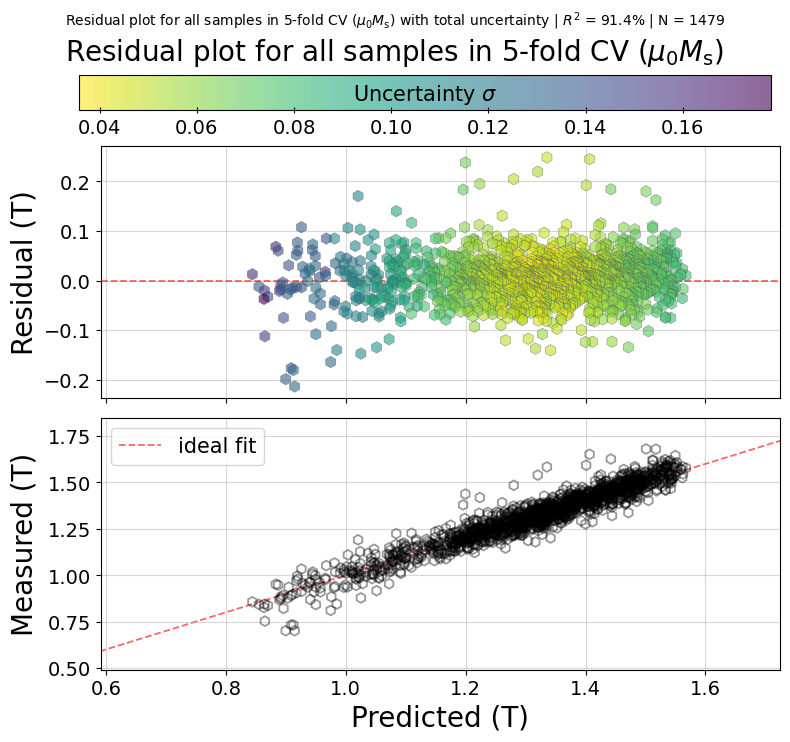

Saved to dir /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ms_bnn/2026-01-19__20-37-51


In [21]:
title = f"Residual plot for all samples in 5-fold CV ({symbol})"
plot_cv_predictions_color_std(y_pred_cv_all, y, std_total_cv_all, 
                              title=title, 
                              details=title+' with total uncertainty',     
                              filename='Ms_all_samples_total_unc', 
                              dirname=MODEL_SAVE_PATH)

## The Confidence Curve

### Single confidence curve plot

Fixed random seed: 123
Trial 1/10: fitting ...
Fitting started at:  2026-01-19 20:41:06
Fitting finished at: 2026-01-19 20:41:25
Total fitting time of BnnMs.Bnn_Magnetization: 18.72 seconds
----------------------------------------------------------------------
Fixed random seed: 124
Trial 2/10: fitting ...
Fitting started at:  2026-01-19 20:41:26
Fitting finished at: 2026-01-19 20:41:44
Total fitting time of BnnMs.Bnn_Magnetization: 18.13 seconds
----------------------------------------------------------------------
Fixed random seed: 125
Trial 3/10: fitting ...
Fitting started at:  2026-01-19 20:41:45
Fitting finished at: 2026-01-19 20:42:03
Total fitting time of BnnMs.Bnn_Magnetization: 18.17 seconds
----------------------------------------------------------------------
Fixed random seed: 126
Trial 4/10: fitting ...
Fitting started at:  2026-01-19 20:42:04
Fitting finished at: 2026-01-19 20:42:22
Total fitting time of BnnMs.Bnn_Magnetization: 17.98 seconds
---------------------------

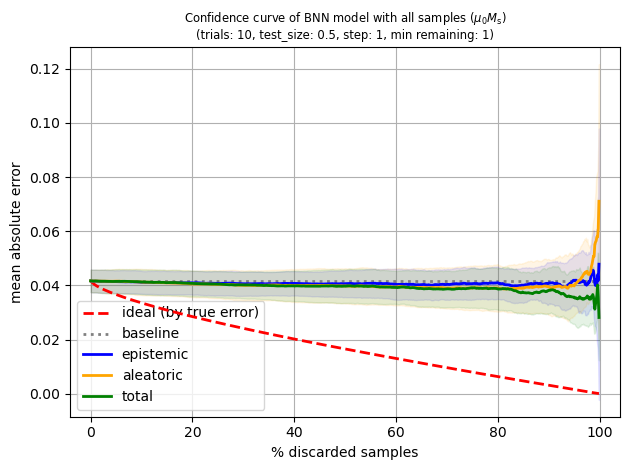

Saved to file: /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ms_bnn/2026-01-19__20-37-51/confidence_curve_Ms_all_samples.png


In [22]:
plot_confidence(
    regressor=regressor,
    df=df,
    features=features_physics,
    label="Ms",
    output_dir=MODEL_SAVE_PATH,
    plot_name=f"confidence_curve_Ms_all_samples",
    title=f"Confidence curve of BNN model with all samples ({symbol})",
    seed=SEED,
    metric="mae",
    n_trials=10,
    test_size=0.5,
    plot_std_total_only=False,
    min_remaining=1,
    step=1
)